# Imaginary noise buildup in the SCF cycle
In this notebook we try to explore the noise buildup that arises as a consequence of the use of `eig` instead of `eigh` when using a complex datatype

In [1]:
from pyscf import gto, scf, mp
import numpy as np
from py_mods.src.MP2.CSMP2 import CS_MP2
from py_mods.src.SCF.CSRHF import CS_RHF
from py_mods.src.SCF.external import RHF_context_from_pyscf
from py_mods.src.SCF.plot_utilities import plot_map

In [2]:
pyscf_args = {
    "atom": "He 0 0 0",
    "spin": 0,
    "charge": 0,
    "basis": f"cc-pv5z",
}

for iteration in range(1,25):
    mol = gto.M(**pyscf_args)
    mol.verbose = 0

    mf = scf.RHF(mol)

    e_He = mf.kernel()
    e_elec = mf.energy_elec()

    mymp = mp.RMP2(mf).run()  # this is UMP2

    # implementation and calculation
    RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
    RHF_cxt.verbose = False
    RHF_cxt.conv_type = None
    RHF_cxt.max_iter = iteration
    # RHF_cxt.theta = 0.1
    RHF_res = CS_RHF(RHF_cxt)
    # print('Number of orbitals is: ', len(RHF_res.X))
    mp_results = CS_MP2(RHF_res)

    MP2_error = (mymp.e_tot - mp_results.E_MP2)
    print(f'\nAt iteration {iteration}:')
    print('He/aug-cc-pvqz MP2 error:', MP2_error)
    print(f"max of imag part of coefficient matrix is {np.max(RHF_res.C_munu.imag):5e}")
    print('Norm of the imaginay part of the density matrix is:', np.linalg.norm(RHF_res.P.imag))


At iteration 1:
He/aug-cc-pvqz MP2 error: (-2.8525350961721774+0j)
max of imag part of coefficient matrix is 0.000000e+00
Norm of the imaginay part of the density matrix is: 0.0

At iteration 2:
He/aug-cc-pvqz MP2 error: (-0.11153323928810899+0j)
max of imag part of coefficient matrix is 0.000000e+00
Norm of the imaginay part of the density matrix is: 0.0

At iteration 3:
He/aug-cc-pvqz MP2 error: (-0.0014100641264209735+0j)
max of imag part of coefficient matrix is 0.000000e+00
Norm of the imaginay part of the density matrix is: 0.0

At iteration 4:
He/aug-cc-pvqz MP2 error: (-4.179066480825e-05+0j)
max of imag part of coefficient matrix is 0.000000e+00
Norm of the imaginay part of the density matrix is: 0.0

At iteration 5:
He/aug-cc-pvqz MP2 error: (-2.8219252805605777e-06+0j)
max of imag part of coefficient matrix is 0.000000e+00
Norm of the imaginay part of the density matrix is: 0.0

At iteration 6:
He/aug-cc-pvqz MP2 error: (-3.7083924064873486e-07+0j)
max of imag part of coeff

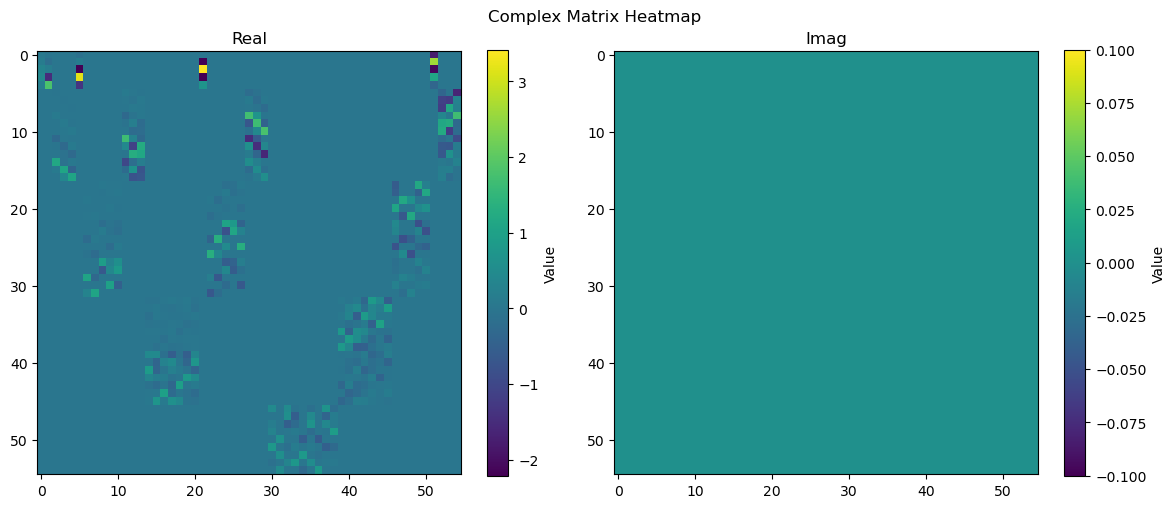

max of imag part of coefficient matrix is 0.000000e+00


In [3]:
plot_map(RHF_res.C_munu)
print(f"max of imag part of coefficient matrix is {np.max(RHF_res.C_munu.imag):5e}")

In [4]:
# implementation and calculation
RHF_iter_2 = RHF_context_from_pyscf(**pyscf_args)
RHF_iter_2.verbose = True
RHF_iter_2.theta = 0.01
RHF_iter_2.conv_type = None
RHF_iter_2 = CS_RHF(RHF_iter_2)

print(f"\n\n\nMax of imag part of coefficient matrix is {np.max(RHF_iter_2.C_munu.imag):5e}")
print('Norm of the imaginay part of the density matrix is:', np.linalg.norm(RHF_iter_2.P.imag))

Converging unscaled case:
--------------------------------------------------------------------------------------------------------------------------------
|   Iter     |                   E_iter                      |                   Delta_e                   |      norm(e_i)      |
--------------------------------------------------------------------------------------------------------------------------------
    0     0.000000E+00+0.000000E+00j     0.000000E+00+0.000000E+00j     0.0000E+00     0.0000E+00j
    1     -2.750010E+00+0.000000E+00j     -2.750010E+00+0.000000E+00j     6.3388E-01     0.0000E+00j
    2     -2.860252E+00+0.000000E+00j     -1.102420E-01+0.000000E+00j     5.2768E-02     0.0000E+00j
    3     -2.861591E+00+0.000000E+00j     -1.339265E-03+0.000000E+00j     7.3467E-03     0.0000E+00j
    4     -2.861624E+00+0.000000E+00j     -3.265637E-05+0.000000E+00j     1.1932E-03     0.0000E+00j
    5     -2.861625E+00+0.000000E+00j     -1.191581E-06+0.000000E+00j     2.1577E-

Symmetric matrix: True


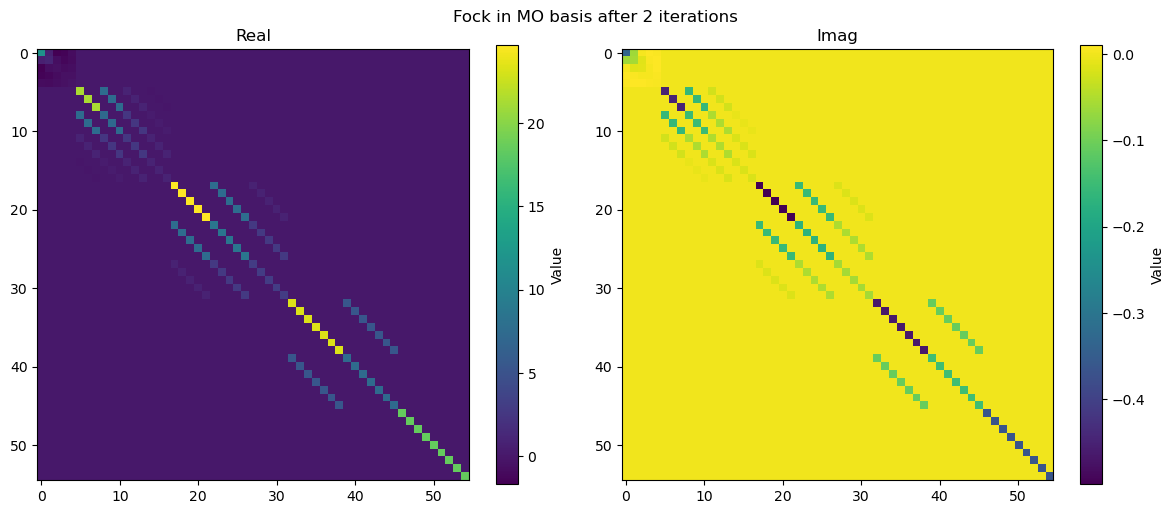

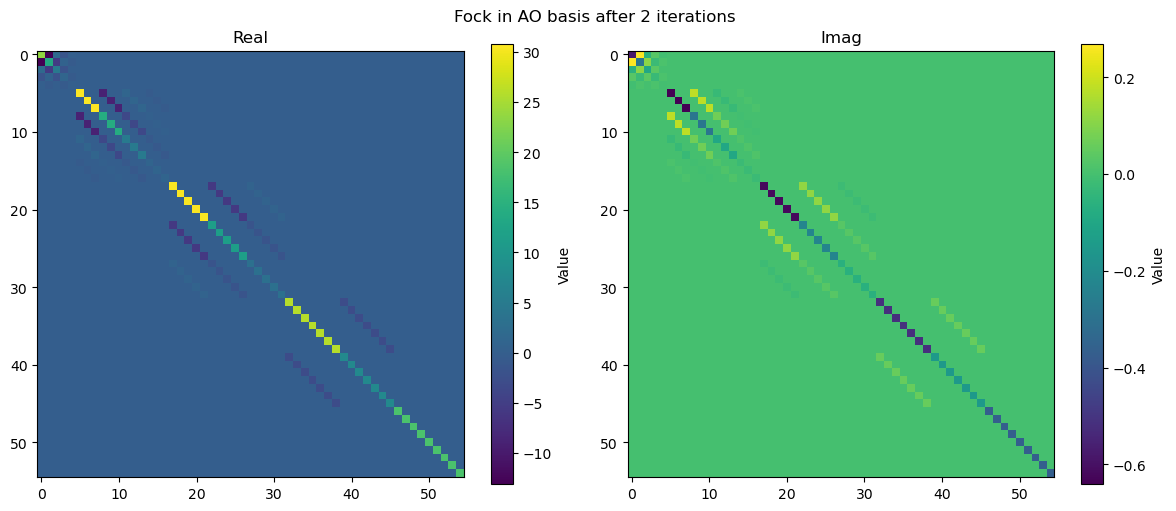

In [5]:
F_2 = RHF_iter_2.F_final
X = RHF_iter_2.X
F_2_ao = X.T @ F_2 @ X

print(f'Symmetric matrix: {np.allclose(F_2_ao.T, F_2_ao)}')

plot_map(F_2, title='Fock in MO basis after 2 iterations')
plot_map(F_2_ao, title='Fock in AO basis after 2 iterations')


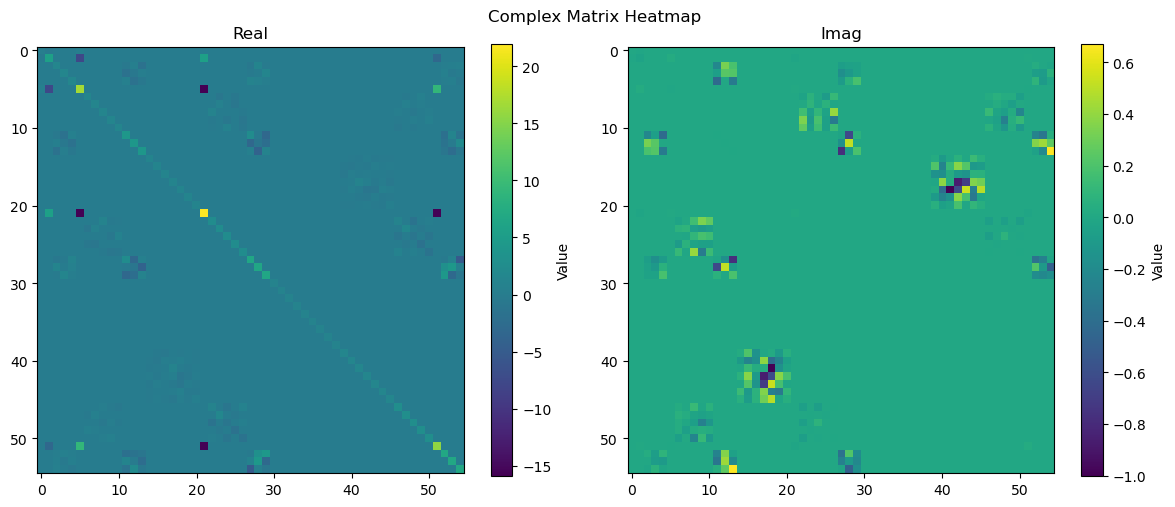

max of imag part of coefficient matrix is 1.087567e+00


In [6]:
plot_map(RHF_iter_2.C_munu.T @ RHF_iter_2.C_munu )
print(f"max of imag part of coefficient matrix is {np.max(RHF_iter_2.C_munu.imag):5e}")